In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer

## Cargamos el dataset

In [5]:
df_crimes = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv")
test_df_crimes = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_test.csv")
df_crimes.describe()

,Unnamed: 0,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station,Day_sin,...,Day Time_Night,Arrest_tag,Domestic_tag,IUCR_freq,Primary_Type_freq,Location_Description_freq,FBI_Code_freq,Crime_District_freq,Nearest_Police_Station_District_freq,Nearest_Police_Station_District_Name_freq
count,203517.000000,203517.000000,203517.000000,203517.000000,2.035170e+05,2.035170e+05,203517.000000,203517.000000,203517.000000,2.035170e+05,...,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000
mean,129147.611816,1157.129036,23.199821,36.236098,1.165231e+06,1.887693e+06,41.847412,-87.669048,7.449639,3.950098e-03,...,0.284821,0.136760,0.183184,0.039938,0.126756,0.132513,0.117452,0.048321,0.052626,0.052626
std,74720.767807,709.255775,13.935122,21.589396,1.619744e+04,3.154949e+04,0.086755,0.051362,0.595763,7.079367e-01,...,0.451330,0.343595,0.386818,0.028798,0.076513,0.105169,0.077244,0.010938,0.022493,0.022493
min,0.000000,111.000000,1.000000,1.000000,1.097306e+06,1.813897e+06,41.644590,-87.768200,5.376451,-9.749279e-01,...,0.000000,0.000000,0.000000,0.000005,0.000015,0.000005,0.000010,0.000059,0.013164,0.013164
25%,64372.000000,533.000000,10.000000,22.000000,1.153909e+06,1.860542e+06,41.772676,-87.705488,7.126770,-7.818315e-01,...,0.000000,0.000000,0.000000,0.009753,0.065454,0.023202,0.055715,0.039667,0.035707,0.035707
50%,128808.000000,1034.000000,23.000000,32.000000,1.167084e+06,1.894421e+06,41.866112,-87.656973,7.534310,-2.449294e-16,...,0.000000,0.000000,0.000000,0.052757,0.110448,0.119931,0.084543,0.051666,0.049038,0.049038
75%,194208.000000,1732.000000,34.000000,53.000000,1.176640e+06,1.910445e+06,41.910022,-87.630560,7.832032,7.818315e-01,...,1.000000,0.000000,0.000000,0.062378,0.177882,0.269810,0.147319,0.053922,0.066820,0.066820
max,258611.000000,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,9.443448,9.749279e-01,...,1.000000,1.000000,1.000000,0.078529,0.234826,0.269810,0.237833,0.067621,0.093314,0.093314


## Normalización y estandarización - Escalado

In [6]:
# Selecciono las columnas de coordenadas para la normalización y estandarización
spatial_columns = ['X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude', 'Distance Crime To Police Station']
df_subset = df_crimes[spatial_columns]
test_df_subset = test_df_crimes[spatial_columns]
df_subset.head()

,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station
0,1186817.0,1860189.0,41.771470,-87.605748,7.221500
1,1179661.0,1873623.0,41.808501,-87.630560,7.230790
2,1145740.0,1853048.0,41.752749,-87.708864,8.289815
3,1184362.0,1861188.0,41.774269,-87.605748,6.913747
4,1137458.0,1907694.0,41.902858,-87.765574,7.494565


In [ ]:
df_subset.describe()

### Evaluamos la distribución de los datos

In [ ]:
# Verifico la distribución de las coordenadas y la distancia
plt.figure(figsize=(20, 20))  # Aumenté la altura para acomodar 5 variables

# 1. Histogramas para visualizar la distribución
for i, col in enumerate(spatial_columns):
    plt.subplot(5, 3, i*3+1)  # 5 filas (una por variable), 3 columnas (histograma, QQ-plot, test)
    sns.histplot(df_crimes[col], kde=True)
    plt.title(f'Distribución de {col}')

    # 2. QQ-plots para comparar con distribución normal
    plt.subplot(5, 3, i*3+2)
    stats.probplot(df_crimes[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot de {col}')

    # 3. Test de normalidad Shapiro-Wilk
    stat, p_value = stats.shapiro(df_crimes[col].sample(min(5000, len(df_crimes))))
    plt.subplot(5, 3, i*3+3)
    plt.text(0.5, 0.5, f'Test Shapiro-Wilk:\nEstadístico: {stat:.4f}\np-valor: {p_value:.4e}\n{"Normal" if p_value > 0.05 else "No Normal"}',
             ha='center', va='center', fontsize=12)
    plt.axis('off')
    plt.title(f'Test de Normalidad para {col}')

plt.tight_layout()
plt.show()

En clase vimos dos opciones de normalización/estandarización

1. Estandarización (StandardScaler):
    * Transforma los datos para que tengan media 0 y desviación estándar 1.
    * Útil cuando los datos siguen una distribución aproximadamente normal.
2. Normalización (MinMaxScaler):
    * Escala los datos al rango [0,1] o [-1,1].
    * Útil cuando no se asume una distribución específica.

**Algunas observaciones**:
1. StandardScaler es menos sensible a valores atípicos que MinMaxScaler.
2. Robustez de StandardScaler:
    * Aunque se basa en la media y desviación estándar, StandardScaler puede ser útil incluso cuando los datos no son perfectamente normales.
    * Es más robusto ante valores atípicos que MinMaxScaler.
3. Cuándo usar MinMaxScaler:
    * Si los datos tienen una distribución claramente no normal
    * Si el algoritmo específico requiere datos en un rango acotado (como [0,1])
    * Si la interpretabilidad de los valores escalados es importante

**Existen otras alternativas como**:
1. RobustScaler: Para datos con distribuciones no normales, RobustScaler puede ser más apropiado, ya que usa la mediana y el rango intercuartílico en lugar de la media y desviación estándar.
2. QuantileTransformer: Transforma las características para seguir una distribución específica.

Se podrían explorar también algunas transformaciones específicas para coordenadas geográficas. Las coordenadas geográficas tienen características especiales que pueden beneficiarse de transformaciones específicas:
1. Transformación Haversine
    * Para datos geoespaciales, una transformación común es convertir las coordenadas (latitud, longitud) en distancias relativas a un punto de referencia.
2. Transformación a coordenadas cartesianas
    * Otra opción es transformar las coordenadas geográficas a un sistema cartesiano local.


### Normalización (Min-Max)

In [7]:
# Normalización (Min-Max)
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_subset), columns=df_subset.columns)
test_df_normalized = pd.DataFrame(scaler.fit_transform(test_df_subset), columns=test_df_subset.columns)
print("Normalizado:\n", df_normalized.head())

Normalizado:
    X Coordinate  Y Coordinate  Latitude  Longitude  \
0      0.830243      0.336434  0.335700   0.812867   
1      0.763869      0.434068  0.433676   0.688712   
2      0.449241      0.284536  0.286167   0.296902   
3      0.807472      0.343695  0.343106   0.812867   
4      0.372423      0.681684  0.683326   0.013137   

   Distance Crime To Police Station  
0                          0.453664  
1                          0.455948  
2                          0.716343  
3                          0.377993  
4                          0.520805  


In [ ]:
df_normalized.describe()

### Estandarización (Z-Score)

In [8]:
# Estandarización (Z-Score)
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df_subset), columns=df_subset.columns)
test_df_standardized = pd.DataFrame(scaler.fit_transform(test_df_subset), columns=test_df_subset.columns)
print("\nEstandarizado:\n", df_standardized.head())


Estandarizado:
    X Coordinate  Y Coordinate  Latitude  Longitude  \
0      1.332680     -0.871761 -0.875358   1.232433   
1      0.890881     -0.445952 -0.448515   0.749342   
2     -1.203344     -1.098104 -1.091157  -0.775216   
3      1.181113     -0.840096 -0.843093   1.232433   
4     -1.714661      0.633973  0.639117  -1.879362   

   Distance Crime To Police Station  
0                         -0.382936  
1                         -0.367342  
2                          1.410255  
3                         -0.899507  
4                          0.075410  


In [ ]:
df_standardized.describe()

### Escalado robusto (RobustScaler)

In [9]:
# Escalado robusto (RobustScaler)
scaler = RobustScaler()
df_robust = pd.DataFrame(scaler.fit_transform(df_subset), columns=df_subset.columns)
test_df_robust = pd.DataFrame(scaler.fit_transform(test_df_subset), columns=test_df_subset.columns)
print("\nEscalado robusto:\n", df_robust.head())


Escalado robusto:
    X Coordinate  Y Coordinate  Latitude  Longitude  \
0      0.868110     -0.685971 -0.689077   0.683652   
1      0.553297     -0.416769 -0.419460   0.352503   
2     -0.938982     -0.829068 -0.825387  -0.692549   
3      0.760107     -0.665952 -0.668697   0.683652   
4     -1.303330      0.265976  0.267546  -1.449419   

   Distance Crime To Police Station  
0                         -0.443536  
1                         -0.430364  
2                          1.071241  
3                         -0.879904  
4                         -0.056354  


In [11]:
df_robust.describe()

,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station
count,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000
mean,-0.081517,-0.134831,-0.136154,-0.161155,-0.120056
std,0.712570,0.632216,0.631655,0.685481,0.844741
min,-3.069729,-1.613610,-1.612881,-1.484458,-3.059655
25%,-0.579605,-0.678897,-0.680299,-0.647497,-0.577856
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.420395,0.321103,0.319701,0.352503,0.422144
max,1.673266,1.143659,1.138992,1.182781,2.706992


### Escalado con quantiles (QuantileTransformer)

In [10]:
# Escalado con quantiles (QuantileTransformer)
qt_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
df_qt = pd.DataFrame(qt_transformer.fit_transform(df_subset), columns=df_subset.columns)
test_df_qt = pd.DataFrame(qt_transformer.fit_transform(df_subset), columns=df_subset.columns)
print("\nEscalado con quantiles:\n", df_qt.head())


Escalado con quantiles:
    X Coordinate  Y Coordinate  Latitude  Longitude  \
0      1.436103     -0.686236 -0.692192   1.186981   
1      0.968052     -0.315196 -0.318792   0.703922   
2     -1.149137     -0.973254 -0.960174  -0.945616   
3      1.314992     -0.647233 -0.651230   1.186981   
4     -1.691867      0.572739  0.577906  -1.340200   

   Distance Crime To Police Station  
0                         -0.546350  
1                         -0.531568  
2                          1.651759  
3                         -0.943309  
4                         -0.082722  


In [13]:
df_qt.describe()

,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station
count,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000
mean,0.005227,0.003712,0.003600,-0.017208,-0.010229
std,1.004737,1.003855,1.003908,1.589831,1.000024
min,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338
25%,-0.679155,-0.676043,-0.675209,-0.595437,-0.677875
50%,0.006273,0.004715,0.004314,0.026349,-0.019340
75%,0.689391,0.683361,0.682821,0.703922,0.659856
max,5.199338,5.199338,5.199338,5.199338,5.199338


### Comparamos resultados

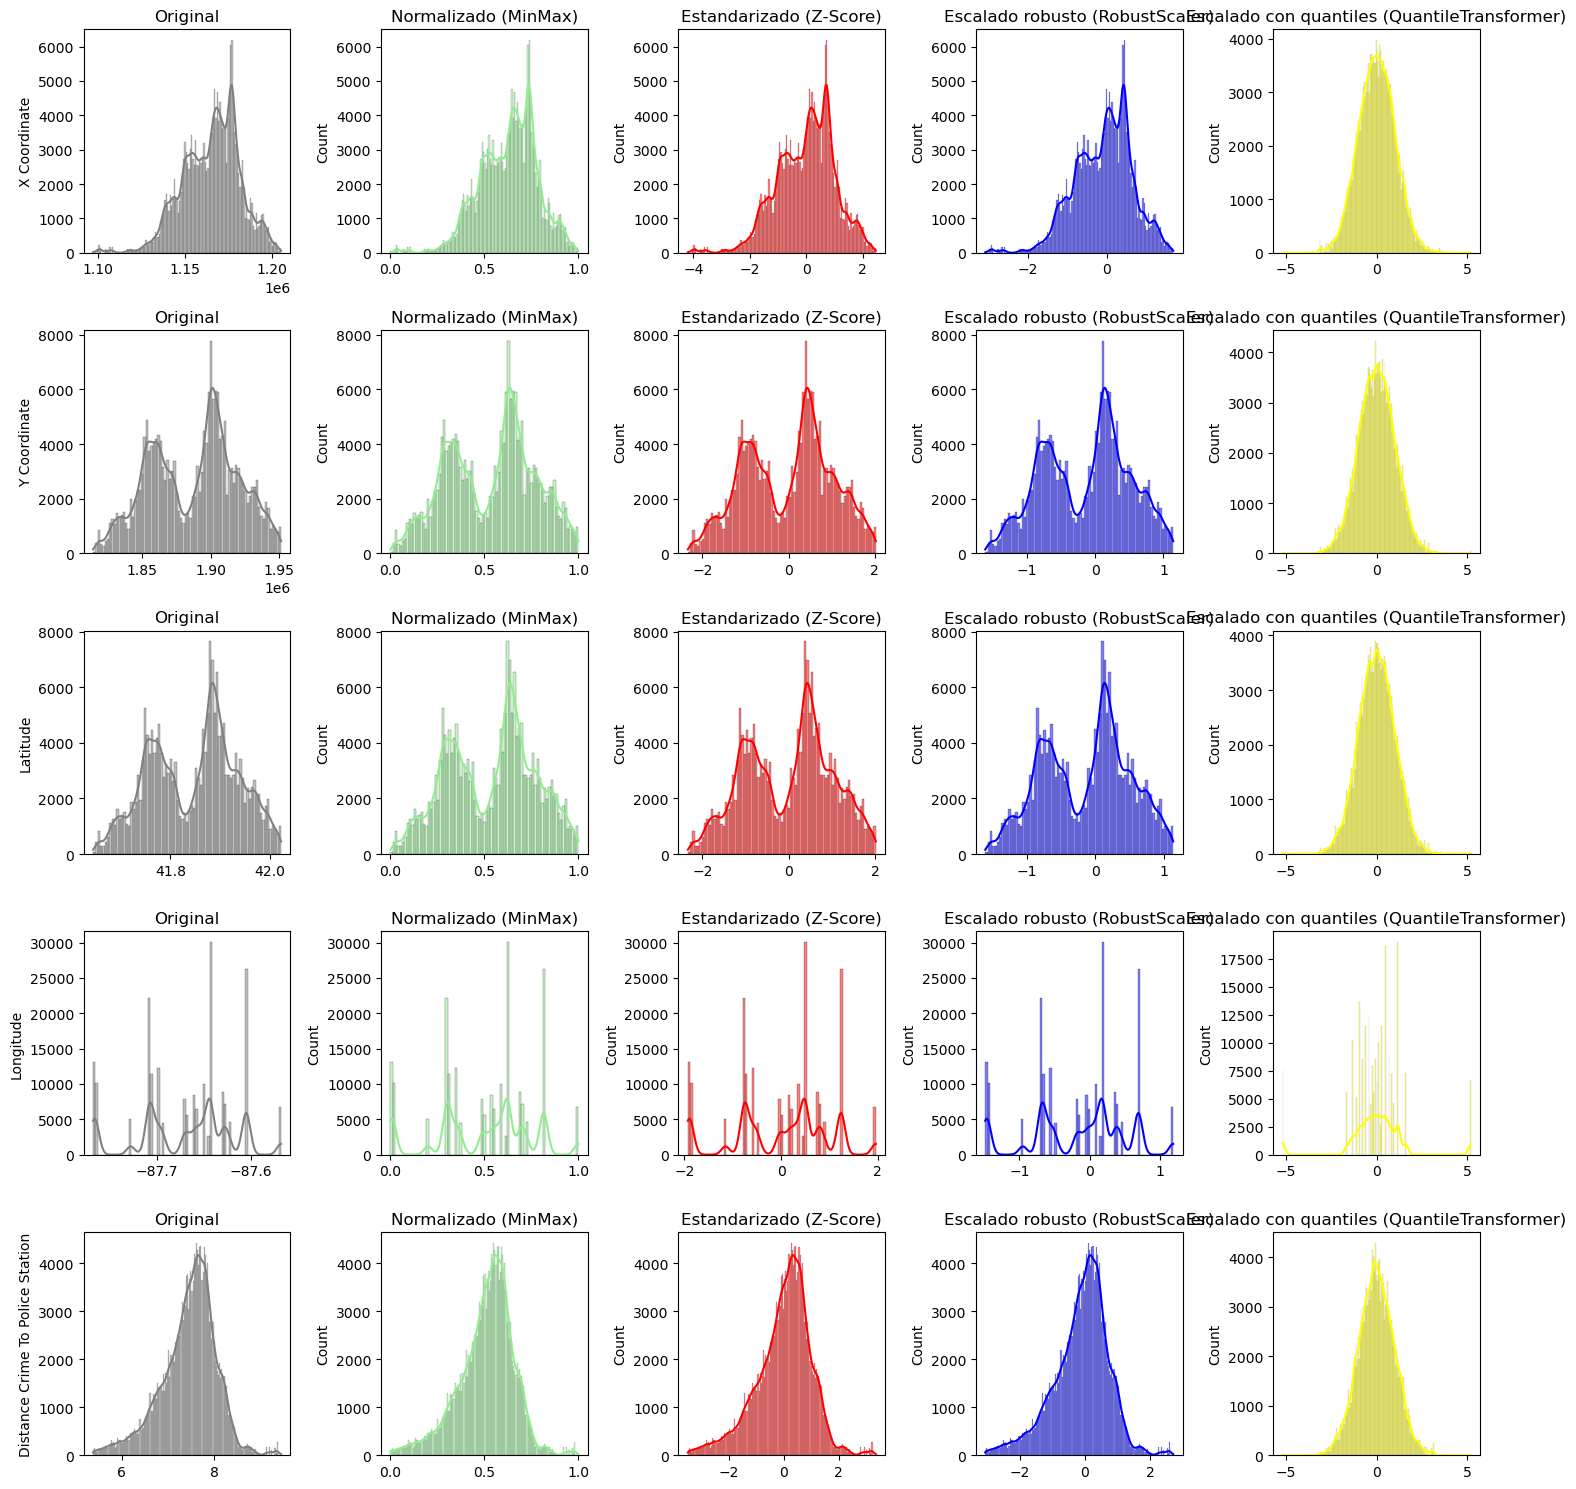

In [14]:
# Gráfico
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(15, 15))
titles = ["Original", "Normalizado (MinMax)", "Estandarizado (Z-Score)", "Escalado robusto (RobustScaler)", "Escalado con quantiles (QuantileTransformer)"]

# Recorrer cada variable y graficarla en las tres columnas
for i, col in enumerate(spatial_columns):
    sns.histplot(df_subset[col], kde=True, ax=axes[i, 0], color="gray")
    sns.histplot(df_normalized[col], kde=True, ax=axes[i, 1], color="lightgreen")
    sns.histplot(df_standardized[col], kde=True, ax=axes[i, 2], color="red")
    sns.histplot(df_robust[col], kde=True, ax=axes[i, 3], color="blue")
    sns.histplot(df_qt[col], kde=True, ax=axes[i, 4], color="yellow")

    # Etiquetas
    axes[i, 0].set_ylabel(col)
    for j in range(5):
        axes[i, j].set_xlabel("")
        axes[i, j].set_title(titles[j])

# Ajustar el layout
plt.tight_layout()
plt.show()

## Salvamos en un archivo

In [11]:
# df_crimes[spatial_columns] = df_standardized[spatial_columns]
# Recorrer cada variable y reemplazarla en dataset original
for i, col in enumerate(spatial_columns):
    df_crimes[f"{col}_standardized"] = df_standardized[col]
    test_df_crimes[f"{col}_standardized"] = test_df_standardized[col]

df_crimes.drop(columns=spatial_columns, inplace=True)
test_df_crimes.drop(columns=spatial_columns, inplace=True)
df_crimes.describe()

,Unnamed: 0,Beat,Ward,Community Area,Day_sin,Season_Spring,Season_Summer,Season_Winter,Day Time_Early Morning,Day Time_Morning,...,Location_Description_freq,FBI_Code_freq,Crime_District_freq,Nearest_Police_Station_District_freq,Nearest_Police_Station_District_Name_freq,X Coordinate_standardized,Y Coordinate_standardized,Latitude_standardized,Longitude_standardized,Distance Crime To Police Station_standardized
count,203517.000000,203517.000000,203517.000000,203517.000000,2.035170e+05,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000,...,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000,2.035170e+05,2.035170e+05,2.035170e+05,2.035170e+05,2.035170e+05
mean,129147.611816,1157.129036,23.199821,36.236098,3.950098e-03,0.246299,0.271638,0.228757,0.197625,0.206052,...,0.132513,0.117452,0.048321,0.052626,0.052626,-2.924049e-15,2.821824e-15,-2.043539e-15,4.141610e-13,1.033151e-15
std,74720.767807,709.255775,13.935122,21.589396,7.079367e-01,0.430856,0.444805,0.420034,0.398208,0.404469,...,0.105169,0.077244,0.010938,0.022493,0.022493,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,0.000000,111.000000,1.000000,1.000000,-9.749279e-01,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000005,0.000010,0.000059,0.013164,0.013164,-4.193578e+00,-2.339046e+00,-2.337877e+00,-1.930478e+00,-3.479892e+00
25%,64372.000000,533.000000,10.000000,22.000000,-7.818315e-01,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.023202,0.055715,0.039667,0.035707,0.035707,-6.990041e-01,-8.605718e-01,-8.614607e-01,-7.094916e-01,-5.419435e-01
50%,128808.000000,1034.000000,23.000000,32.000000,-2.449294e-16,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.119931,0.084543,0.051666,0.049038,0.049038,1.143982e-01,2.132676e-01,2.155523e-01,2.350984e-01,1.421216e-01
75%,194208.000000,1732.000000,34.000000,53.000000,7.818315e-01,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.269810,0.147319,0.053922,0.066820,0.066820,7.043696e-01,7.211694e-01,7.216867e-01,7.493415e-01,6.418548e-01
max,258611.000000,2535.000000,50.000000,77.000000,9.749279e-01,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.269810,0.237833,0.067621,0.093314,0.093314,2.462615e+00,2.022240e+00,2.018745e+00,1.960579e+00,3.346654e+00


In [12]:
df_crimes.to_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized.csv", index=False)
test_df_crimes.to_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized_test.csv", index=False)